In [1]:
from tqdm import tqdm
import random, os
from pathlib import Path

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from utils.cs_utils import *
from utils.pauli_utils import *
from utils.shadow_utils import *

In [2]:
err_key = ['MAE', 'MRE', 'RMSE', 'RRMSE', 'Huber', 'Rel. Huber', 'SNR (dB)', 'Ljung']
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
models = {'heis': 'Heisenberg', 'tfim': 'TFIM'}

plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.title_fontsize'] = 14
plt.rcParams['legend.fontsize'] = 12
# plt.rcdefaults()

In [3]:
def get_L(Nq, Nx, Ny, ham, gamma=1e-2, eps=1e-1, seed=42):
    G = nx.generators.lattice.grid_2d_graph(Nx,Ny)
    G = nx.convert_node_labels_to_integers(G)
    H_ops = get_h_ops(Nq, model=ham, graph=G, seed=seed, eps=eps)

    c_ops = []
    rng = np.random.default_rng(seed+1)
    ad_gammas = ([np.sqrt(gamma)]*Nq) * (1 + eps * rng.uniform(low=-1, high=1, size=Nq))  # amplitude damping rates
    ad_ops = amp_damp_ops(Nq)
    c_ops += [gamma * op for (gamma,op) in zip(ad_gammas, ad_ops)]

    dz_gammas = ([np.sqrt(gamma)]*Nq) * (1 + eps * rng.uniform(low=-1, high=1, size=Nq))  # dephasing rates
    dz_ops = [p2op(z) for z in pbw(Nq,nb=1,ptype='Z')]
    c_ops += [gamma * op for (gamma,op) in zip(dz_gammas, dz_ops)]

    H = ps2op(H_ops)
    L = qt.liouvillian(H, c_ops)
    return L

def gini_sparsity(v):
    v = np.abs(v)
    if np.sum(v) == 0:
        return 1.0
    v = np.sort(v)          # ascending
    n = len(v)
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * v)) / (n * np.sum(v)) - (n + 1) / n
    return gini / (1 - 1/n)

def hoyer_sparsity(v):
    n = len(v)
    l1 = np.sum(np.abs(v))
    l2 = np.linalg.norm(v)
    if l2 == 0: return 1.0
    return (np.sqrt(n) - l1/l2) / (np.sqrt(n) - 1)

def effective_sparsity(v, tol=1e-1):
    k = np.sum(np.abs(v) > tol)   # number of "active" components
    return 1 - k / len(v)

def get_sparsity(x, type):
    if type == 'gini':
        return gini_sparsity(x)
    elif type == 'hoyer':
        return hoyer_sparsity(x)
    elif type == 'effective':
        return effective_sparsity(x)
    else:
        raise ValueError(f"Unknown sparsity type: {type}")

def color_violin(output, color):
    for pc in output['bodies']:
        pc.set_facecolor(color)   # fill color

    for part_name in ('cbars', 'cmins', 'cmaxes', 'cmeans', 'cmedians'):
        if part_name in output:
            output[part_name].set_edgecolor(color)

def save_plot(fig, filedir, filename):
    filedir = Path(filedir)
    filedir.mkdir(parents=True, exist_ok=True)
    filename = Path(filename)
    if filename.suffix == "":
        filename = filename.with_suffix(".png")
    fig.savefig(filedir / filename, dpi=300, bbox_inches='tight')
    return

def COB(n_qubits):
    """Columns are vectorized, normalized n-qubit Pauli operators."""
    paulis_1q = [qt.qeye(2), qt.sigmax(), qt.sigmay(), qt.sigmaz()]
    cols = []
    for combo in itertools.product(paulis_1q, repeat=n_qubits):
        P = qt.tensor(*combo) if n_qubits > 1 else combo[0]
        cols.append(qt.operator_to_vector(P).full().flatten())
    B = np.column_stack(cols) / np.sqrt(2**n_qubits)
    B = qt.Qobj(B)
    B.dims = [[[2]*n_qubits]*2, [[2]*n_qubits]*2]  # match operator_to_vector's dims convention
    return B

In [13]:
#specify info
NX = 2
NY = 2
HAM = 'tfim'
ISTATE = 'ghz'
NQ = NX * NY
U = COB(NQ)
d = 2**NQ
NB = 4
ostrings = pbw(NQ, nb=NB, max=True)
# ostrings = random.sample(ostrings, 10)
NUM_PAULIS = len(ostrings)
INDS = get_inds(NQ)
EPS = 0.1
GAMMA = 1e-2

if EPS:
    LABEL = f"{NX}x{NY}_{HAM}_{ISTATE}_eps={EPS:.1e}"
else:
    LABEL = f"{NX}x{NY}_{HAM}_{ISTATE}"
PLOT_DIR = Path("plots/") / LABEL

In [14]:
epss = np.linspace(0,0.3,13)  #should contain EPS
init_state = get_init_state(NQ, ISTATE)
trials = 10
state_sparsities = np.zeros((trials, len(epss)), dtype=np.float64)
observable_sparsities = np.zeros((trials, len(epss), NUM_PAULIS), dtype=np.float64)
for ii in tqdm(range(trials)):
    for jj in tqdm(range(len(epss))):
        eps = epss[jj]
        if ii == 0:
            seed = 42
        else:
            seed = ii
        L = get_L(NQ, NX, NY, HAM, eps=eps, gamma=GAMMA, seed=seed)
        Lp = U.dag() * L * U
        _, V = np.linalg.eig(Lp.full())
        cn = np.linalg.cond(V)
        if cn > 1e6:
            print(f"Warning: Condition number of V is large ({cn:.2e}) for trial {ii}, eps {eps:.2f}. Results may be inaccurate.")
        Vinv = np.linalg.inv(V)
        state_sparsities[ii, jj] = get_sparsity(expand_into(Vinv=Vinv, state=init_state, U=U), type='gini')
        temp = np.zeros(NUM_PAULIS, dtype=np.float64)
        for kk in range(NUM_PAULIS):
            temp[kk] = get_sparsity(expand_into(V=V, observable=p2op(ostrings[kk]), U=U), type='gini')
        observable_sparsities[ii, jj, :] = temp

100%|██████████| 10/10 [00:37<00:00,  3.77s/it]


In [7]:
def plot_sparsities(epss, state_sparsities, observable_sparsities, pauli_inds, mode=1, filedir=None, filename=None):
    nrows,ncols = 1,5
    fig, axes = plt.subplots(nrows,ncols,figsize=(4*ncols,4*nrows),gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
    step = 4
    pos = range(1, len(epss) + 1, step)
    if mode not in [1, 2]:
        raise ValueError(f"Unknown mode: {mode}")

    kwargs = dict(showmeans=True, showmedians=False, showextrema=True, widths=0.02, positions=epss)
    for ii in range(4):
        if mode == 1:
            data = observable_sparsities[0,:,pauli_inds[ii+1]]
        elif mode == 2:
            data = observable_sparsities[:,:,pauli_inds[ii+1]].mean(axis=2)
        output = axes[ii].violinplot(data, **kwargs)
        color_violin(output, f'C{ii}')
        axes[ii].set_title(f'Weight {ii+1}')

    if mode == 1:
        output = axes[-1].plot(epss, state_sparsities[0,:], color='black', linewidth=1, marker='.')
    elif mode == 2:
        output = axes[-1].violinplot(state_sparsities, **kwargs)
        color_violin(output, 'black')
        # output = axes[-1].plot(epss, state_sparsities.mean(axis=0), color='black', linewidth=1)

    for ax in axes[1:]:
        ax.sharey(axes[0])
        ax.sharex(axes[0])
        ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

    for ax in axes:
        ax.grid()
        ax.minorticks_on()

    if mode == 1:
        fig.suptitle('Operator sparsity (single trial)', y=1.01)
    elif mode == 2:
        fig.suptitle(f'Operator sparsity (over {trials} trials)', y=1.01)

    axes[0].set_xlabel(rf'$\epsilon$')
    axes[0].set_ylabel('Gini sparsity')
    axes[-1].set_title('Initial state')

    return fig

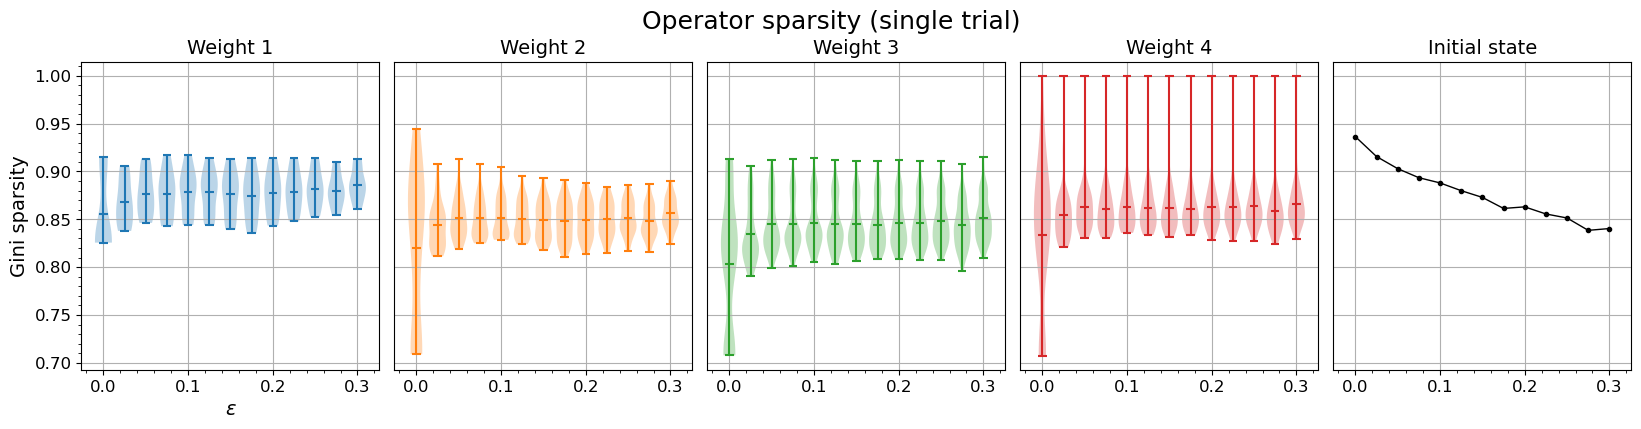

In [87]:
fig = plot_sparsities(epss, state_sparsities, observable_sparsities, pauli_inds=INDS, mode=1)
save_plot(fig, filedir=PLOT_DIR, filename="sparsities_single")

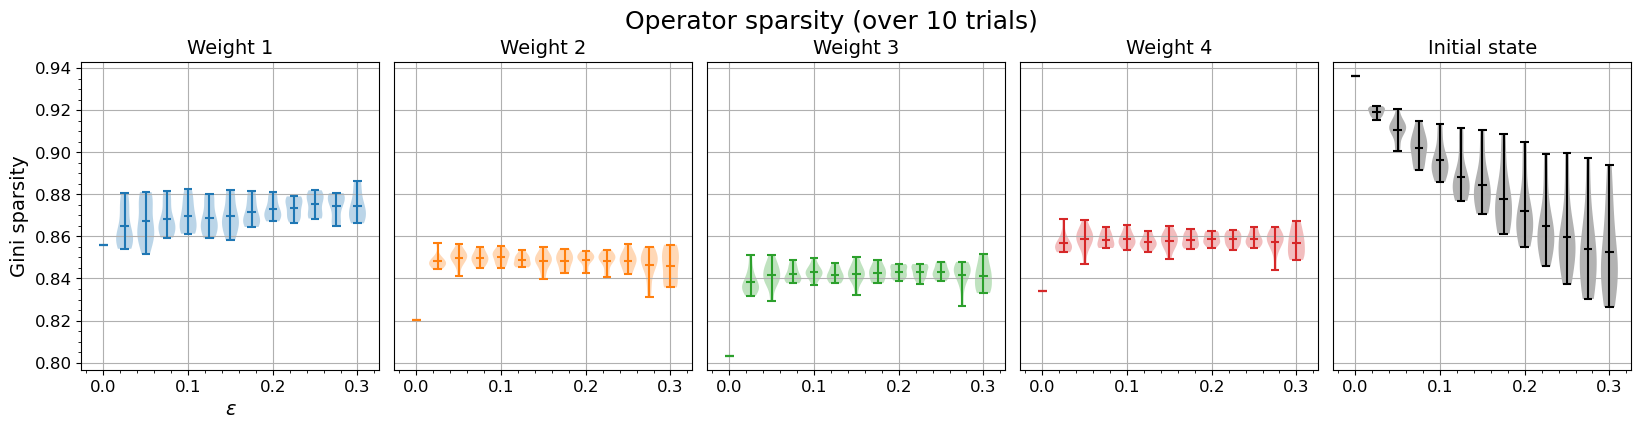

In [88]:
fig = plot_sparsities(epss, state_sparsities, observable_sparsities, pauli_inds=INDS, mode=2)
save_plot(fig, filedir=PLOT_DIR, filename="sparsities_many")